## Stage 5 — Highlight Detection, Phase 1: Geometric Filter

##What the Geometric Filter does

Before any learning, we use pure math on the embeddings to find segments that are "interesting" — no training required. The idea: a highlight is a moment where all 3 modalities agree strongly AND the segment is locally different from its neighbors.

##The 3 geometric signals we compute

    Signal 1: Cross-modal Coherence
    How well do vision, audio, and text agree with each other?
    High coherence = all modalities tell the same story = meaningful moment

    Signal 2: Local Novelty
    How different is this segment from the ones around it?
    High novelty = something changed = potential highlight boundary

    Signal 3: Temporal Saliency
    How different is this segment from the global video average?
    High saliency = this moment stands out from the whole video

---



In [1]:
# ── CELL 1: Mount Drive & Configure Paths ────────────────────────────────
import sys, os
from google.colab import drive

drive.mount('/content/drive')

PROJECT_ROOT   = "/content/drive/MyDrive/PFA"
IMAGEBIND_ROOT = "/content/drive/MyDrive/PFA/ImageBind"
LIB_ROOT       = "/content/drive/MyDrive/PFA/ImageBind/ImageBind"

for p in [LIB_ROOT, IMAGEBIND_ROOT, PROJECT_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

INPUT_DIR  = os.path.join(PROJECT_ROOT, "data")
OUTPUT_DIR = os.path.join(IMAGEBIND_ROOT, "results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_VIDEO = "Obama_Yes_we_can.mp4"
VIDEO_PATH   = os.path.join(INPUT_DIR, TARGET_VIDEO)
VIDEO_STEM   = os.path.splitext(TARGET_VIDEO)[0]

TEXTS_PATH   = os.path.join(OUTPUT_DIR, f"{VIDEO_STEM}_segment_texts.json")
EMB_PATH     = os.path.join(OUTPUT_DIR, f"{VIDEO_STEM}_embeddings_final.npz")

print(f"Input : {INPUT_DIR}")
print(f"Output: {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Input : /content/drive/MyDrive/PFA/data
Output: /content/drive/MyDrive/PFA/ImageBind/results


## Module-based execution (resumed)

This section uses the Python package in `Multimodal/Geometric_Filter` instead of redefining functions in notebook cells.
You can test `window_size=1` (segment), `2` (pair), `3` (triplet), or any valid integer up to the number of segments.

In [2]:
import os
import sys
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Resolve package path
if "PROJECT_ROOT" in globals():
    MULTIMODAL_ROOT = os.path.join(PROJECT_ROOT, "Geometric_Filter")
else:
    MULTIMODAL_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

if MULTIMODAL_ROOT not in sys.path:
    sys.path.insert(0, MULTIMODAL_ROOT)

from Geometric_Filter import get_highlights_by_window, save_geo_scores, save_top_segments

print("Multimodal root:", MULTIMODAL_ROOT)

Multimodal root: /content/drive/MyDrive/PFA/Geometric_Filter


In [3]:
# Load Stage 4 outputs and per-modality embeddings.
UNIFIED_PATH = os.path.join(OUTPUT_DIR, f"{VIDEO_STEM}_unified_final.npz")

npz = np.load(UNIFIED_PATH, allow_pickle=True)
unified = torch.tensor(npz["unified"])      # [N, D]
times = npz["times"]                         # [N, 2]
texts = npz["raw_text"]                      # [N]
trust = torch.tensor(npz["text_trust"])      # [N]

emb_npz = np.load(EMB_PATH, allow_pickle=True)
V = F.normalize(torch.tensor(emb_npz["vision"]), dim=-1)
A = F.normalize(torch.tensor(emb_npz["audio"]), dim=-1)
T = F.normalize(torch.tensor(emb_npz["text"]), dim=-1)

print("unified:", tuple(unified.shape))
print("V/A/T:", tuple(V.shape), tuple(A.shape), tuple(T.shape))
print("segments:", len(times))

unified: (88, 512)
V/A/T: (88, 1024) (88, 1024) (88, 1024)
segments: 88


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Run geometric filtering with generalized window size.
# Examples: 1=segment, 2=pair, 3=triplet, 4+=larger windows.
WINDOW_SIZE = 3
CONTEXT_WINDOW = 5
TOP_K = 20
MIN_GAP_S = 2.0

W_COHERENCE = 0.5
W_NOVELTY = 0.3
W_SALIENCY = 0.2

results, scores = get_highlights_by_window(
    unified=unified,
    V=V,
    A=A,
    T=T,
    trust=trust,
    times=times,
    texts=texts,
    window_size=WINDOW_SIZE,
    context_window=CONTEXT_WINDOW,
    top_k=TOP_K,
    min_gap_s=MIN_GAP_S,
    w_coherence=W_COHERENCE,
    w_novelty=W_NOVELTY,
    w_saliency=W_SALIENCY,
)

print("window_size:", WINDOW_SIZE)
print("returned highlights:", len(results))
print("score stats:")
print("  mean=%.3f std=%.3f min=%.3f max=%.3f" % (
    scores["geo_score"].mean().item(),
    scores["geo_score"].std().item(),
    scores["geo_score"].min().item(),
    scores["geo_score"].max().item(),
))

print("\nTop 10 highlights preview:")
for r in results[:10]:
    t0, t1 = r["times"]
    print(
        "#%02d [%.1fs -> %.1fs] score=%.3f coh=%.2f nov=%.2f sal=%.2f | %s" % (
            r["rank"], t0, t1, r["geo_score"], r["coherence"], r["novelty"], r["saliency"], r["text"][:70]
        )
    )

window_size: 3
returned highlights: 20
score stats:
  mean=0.420 std=0.094 min=0.226 max=0.669

Top 10 highlights preview:
#01 [1.0s -> 3.0s] score=0.669 coh=0.63 nov=0.68 sal=0.74 | Applause. a close up of a man in a suit and tie speaking into a microp
#02 [3.0s -> 5.0s] score=0.595 coh=0.62 nov=0.64 sal=0.47 | My fellow Americans.
#03 [27.0s -> 29.0s] score=0.583 coh=0.87 nov=0.26 sal=0.36 | I don't ask of you as your president.
#04 [36.0s -> 38.0s] score=0.574 coh=0.63 nov=0.44 sal=0.63 | You too believe.
#05 [86.0s -> 88.0s] score=0.531 coh=0.28 nov=0.80 sal=0.75 | Thank you.
#06 [60.0s -> 62.0s] score=0.527 coh=0.69 nov=0.33 sal=0.41 | reaffirmed by those who
#07 [14.0s -> 16.0s] score=0.514 coh=0.72 nov=0.29 sal=0.33 | with you as a citizen.
#08 [58.0s -> 60.0s] score=0.512 coh=0.54 nov=0.44 sal=0.53 | That creep!
#09 [67.0s -> 69.0s] score=0.510 coh=0.55 nov=0.45 sal=0.51 | the core of every American who's story
#10 [84.0s -> 86.0s] score=0.507 coh=0.40 nov=0.73 sal=0.45 | GEORG

In [6]:
# Save outputs using Geometric_Filter I/O helpers.
geo_path = save_geo_scores(
    geo_score=scores["geo_score"],
    components=scores,
    times=times,
    texts=texts,
    output_dir=OUTPUT_DIR,
    video_stem=VIDEO_STEM,
    window_size=WINDOW_SIZE,
)

top_path = save_top_segments(
    results=results,
    scores=scores,
    output_dir=OUTPUT_DIR,
    video_stem=VIDEO_STEM,
    window_size=WINDOW_SIZE,
)

print("Saved geo scores:", geo_path)
print("Saved top highlights:", top_path)

✓ Saved 88 segment scores → /content/drive/MyDrive/PFA/ImageBind/results/Obama_Yes_we_can_geo_scores_triplet.npz
✓ Saved top 20 highlights → /content/drive/MyDrive/PFA/ImageBind/results/Obama_Yes_we_can_top20_triplet.npz

Rank     Start     End   Score    Coh    Nov    Sal  Text
────────────────────────────────────────────────────────────────────────────────────────────
  #1       1.0s    3.0s   0.669   0.63   0.68   0.74  Applause. a close up of a man in a suit and t
  #2       3.0s    5.0s   0.595   0.62   0.64   0.47  My fellow Americans.
  #3      27.0s   29.0s   0.583   0.87   0.26   0.36  I don't ask of you as your president.
  #4      36.0s   38.0s   0.574   0.63   0.44   0.63  You too believe.
  #5      86.0s   88.0s   0.531   0.28   0.80   0.75  Thank you.
  #6      60.0s   62.0s   0.527   0.69   0.33   0.41  reaffirmed by those who
  #7      14.0s   16.0s   0.514   0.72   0.29   0.33  with you as a citizen.
  #8      58.0s   60.0s   0.512   0.54   0.44   0.53  That creep!
  #

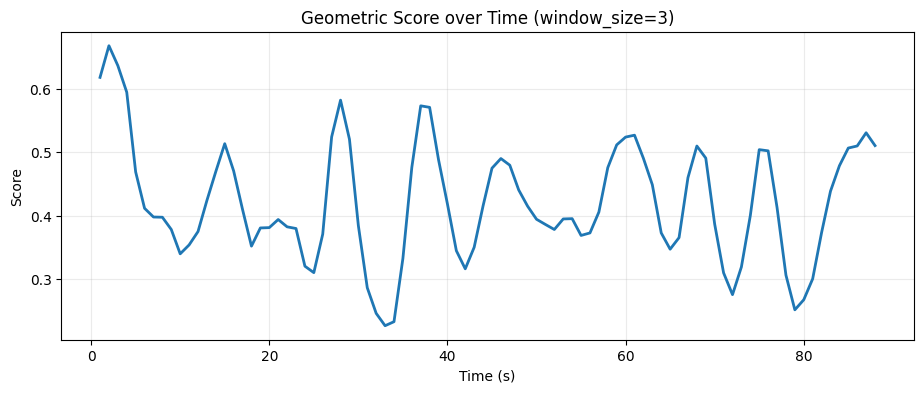

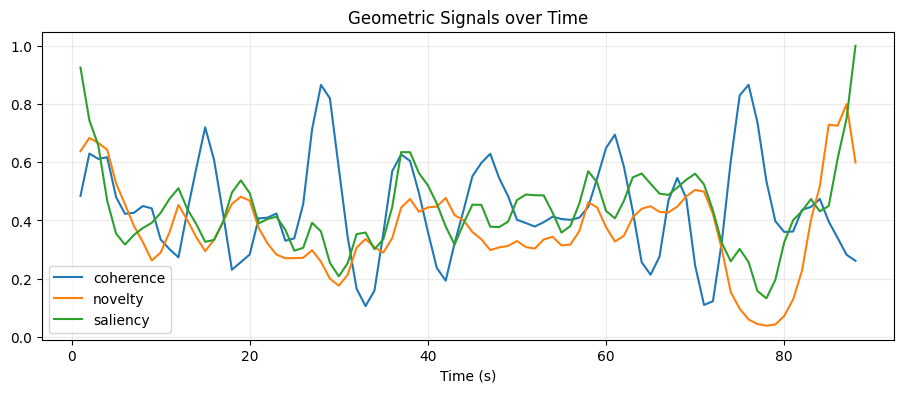

In [7]:
# Quick plots for score interpretation.
geo_npz = np.load(geo_path, allow_pickle=True)
plot_times = geo_npz["times"]
mid_times = (plot_times[:, 0] + plot_times[:, 1]) / 2.0

plt.figure(figsize=(11, 4))
plt.plot(mid_times, geo_npz["geo_score"], linewidth=2)
plt.title(f"Geometric Score over Time (window_size={WINDOW_SIZE})")
plt.xlabel("Time (s)")
plt.ylabel("Score")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(11, 4))
plt.plot(mid_times, geo_npz["coherence"], label="coherence")
plt.plot(mid_times, geo_npz["novelty"], label="novelty")
plt.plot(mid_times, geo_npz["saliency"], label="saliency")
plt.title("Geometric Signals over Time")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()